In [1]:
%reload_ext autoreload
%autoreload 2
import os
from pathlib import Path

import sinter
import matplotlib.pyplot as plt

from qecdec.experiments import StimFileExperiment
from qecdec.decoders import BPDecoder, BPOSDDecoder
from qecdec.sinter_utils import QecdecSinterDecoder

In [2]:
n, k, d = 144, 12, 12
rounds = d
basis = "Z"
code_name = f"BB_{n}_{k}_{d}"
noise_model = "CircuitLevel"
circuit_dir = Path(
    f"../../../circuits/{code_name}_{noise_model}/d={d}_rounds={rounds}_basis={basis}"
).resolve()

In [3]:
def generate_sinter_tasks_and_custom_decoders():
    tasks: list[sinter.Task] = []
    custom_decoders: dict[str, sinter.Decoder] = {}
    for p in [0.002, 0.003, 0.004, 0.005]:
        # Setup the experiment.
        circuit_file = circuit_dir / f"error_rate={p}.stim"
        expmt = StimFileExperiment.load_from_file(circuit_file, basis)

        # Setup a sinter.Task with BP decoder.
        bp = BPDecoder(expmt.chkmat, expmt.prior, max_iter=50)
        custom_decoder_id = f"custom_decoder_{len(custom_decoders)}"
        custom_decoders[custom_decoder_id] = QecdecSinterDecoder(bp, expmt.obsmat)
        tasks.append(
            sinter.Task(
                circuit=expmt.circuit,
                detector_error_model=expmt.dem,
                decoder=custom_decoder_id,
                json_metadata={"p": p, "decoder": "bp"},
            )
        )

        # Setup a sinter.Task with BP+OSD decoder.
        bposd = BPOSDDecoder(
            expmt.chkmat, expmt.prior, max_bp_iter=50, osd_method="OSD_CS", osd_order=10
        )
        custom_decoder_id = f"custom_decoder_{len(custom_decoders)}"
        custom_decoders[custom_decoder_id] = QecdecSinterDecoder(bposd, expmt.obsmat)
        tasks.append(
            sinter.Task(
                circuit=expmt.circuit,
                detector_error_model=expmt.dem,
                decoder=custom_decoder_id,
                json_metadata={"p": p, "decoder": "bposd"},
            )
        )

    return tasks, custom_decoders


tasks, custom_decoders = generate_sinter_tasks_and_custom_decoders()


In [4]:
sinter_stats = sinter.collect(
    num_workers=os.cpu_count() - 1,
    max_shots=10_000_000,
    max_errors=100,
    tasks=tasks,
    custom_decoders=custom_decoders,
    # print_progress=True,
)

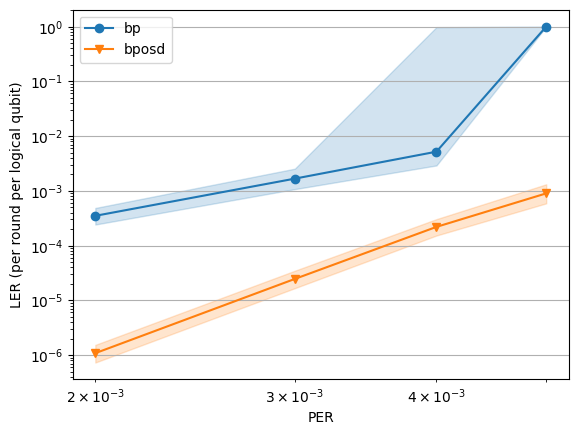

In [5]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=sinter_stats,
    group_func=lambda stat: f"{stat.json_metadata['decoder']}",
    failure_units_per_shot_func=lambda _: rounds * k,
    x_func=lambda stat: stat.json_metadata["p"],
)
ax.loglog()
ax.grid()
ax.set_ylabel("LER (per round per logical qubit)")
ax.set_xlabel("PER")
ax.legend()